In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# Model Selection and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [7]:
data_path = Path('../data/preprocessed_pokemon_data.csv')
pkmn_df = pd.read_csv(data_path)
seed = 42

In [8]:
target = ['tier']
X = pkmn_df.drop(columns=[t for t in target])
y = pkmn_df[target]

# 80% train 20% test, stratify is to make sure the tier distribution is more even in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

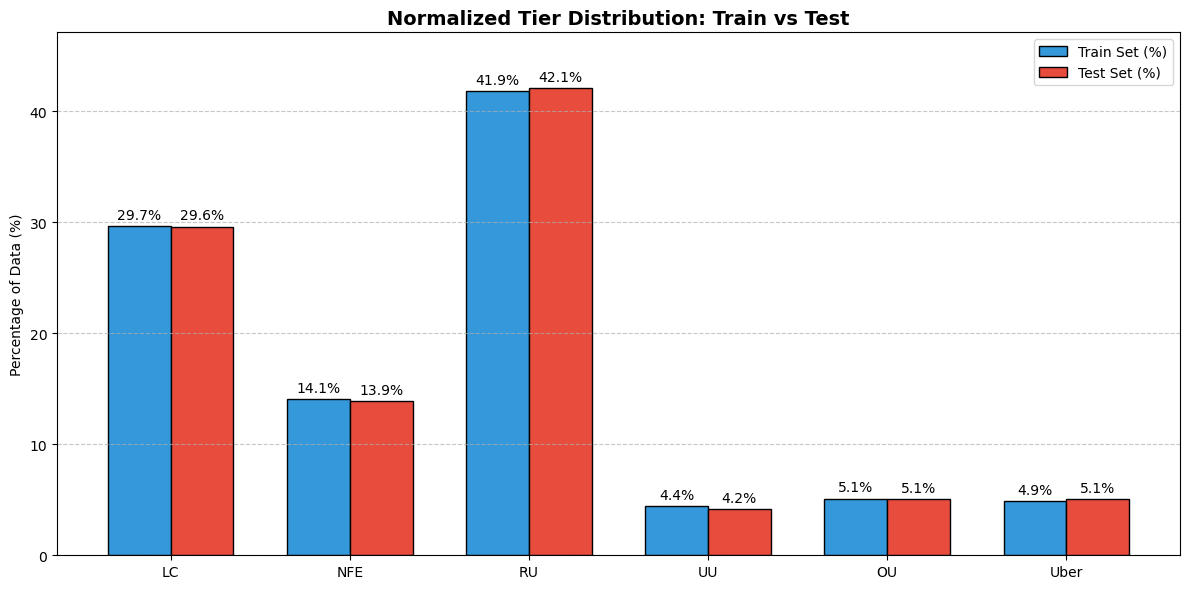

In [9]:
# graph train/test set tier frequency
tier_labels = ['LC', 'NFE', 'RU', 'UU', 'OU', 'Uber']

train_freq = (pd.Series(np.array(y_train).ravel()).value_counts(normalize=True) * 100).reindex(range(len(tier_labels)), fill_value=0)
test_freq = (pd.Series(np.array(y_test).ravel()).value_counts(normalize=True) * 100).reindex(range(len(tier_labels)), fill_value=0)

x = np.arange(len(tier_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, train_freq, width, label='Train Set (%)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, test_freq, width, label='Test Set (%)', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Percentage of Data (%)')
ax.set_title('Normalized Tier Distribution: Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.set_ylim(0, max(train_freq.max(), test_freq.max()) + 5)
ax.legend()

ax.bar_label(rects1, fmt='%.1f%%', padding=3)
ax.bar_label(rects2, fmt='%.1f%%', padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

In [10]:
'''
NOTE: objective: multi-softclass essentially tells the model it is doing a classification problem
given multiple classes like OU, UU, etc. choose the most fitting one and output; softmax converts tier scores->probabilities

'''

tier_model = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.1,
    max_depth=6,
    num_class=len(np.unique(y))
)

tier_model.fit(X_train, y_train)
predictions = tier_model.predict(X_test)


print(classification_report(y_test, predictions, zero_division=0))

mae = mean_absolute_error(y_test, predictions)


              precision    recall  f1-score   support

           0       0.91      0.95      0.93        64
           1       0.83      0.67      0.74        30
           2       0.78      0.90      0.84        91
           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00        11
           5       0.64      0.64      0.64        11

    accuracy                           0.79       216
   macro avg       0.53      0.53      0.52       216
weighted avg       0.75      0.79      0.76       216



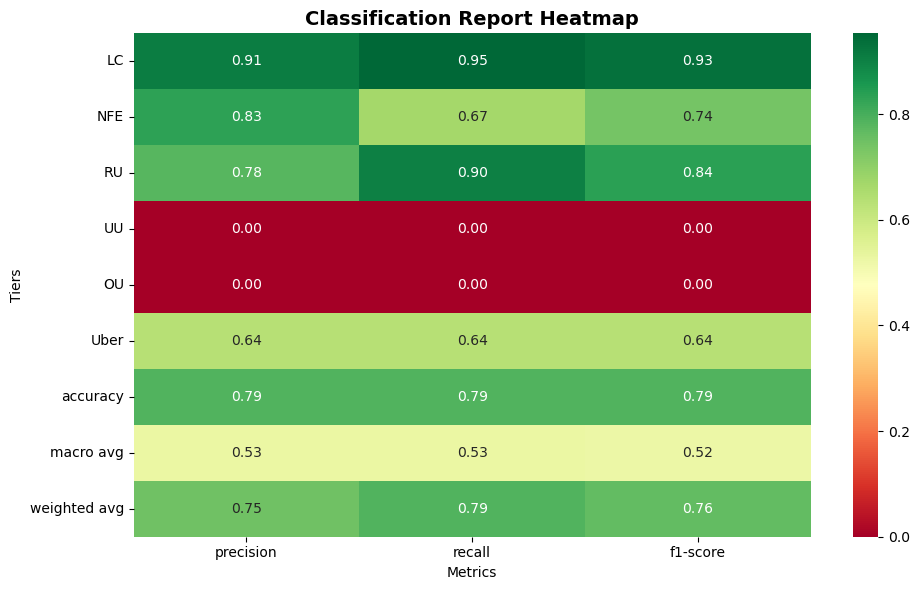

In [11]:
report_dict = classification_report(y_test, predictions, target_names=tier_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax)

ax.set_title('Classification Report Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrics')
ax.set_ylabel('Tiers')

plt.tight_layout()
plt.show()

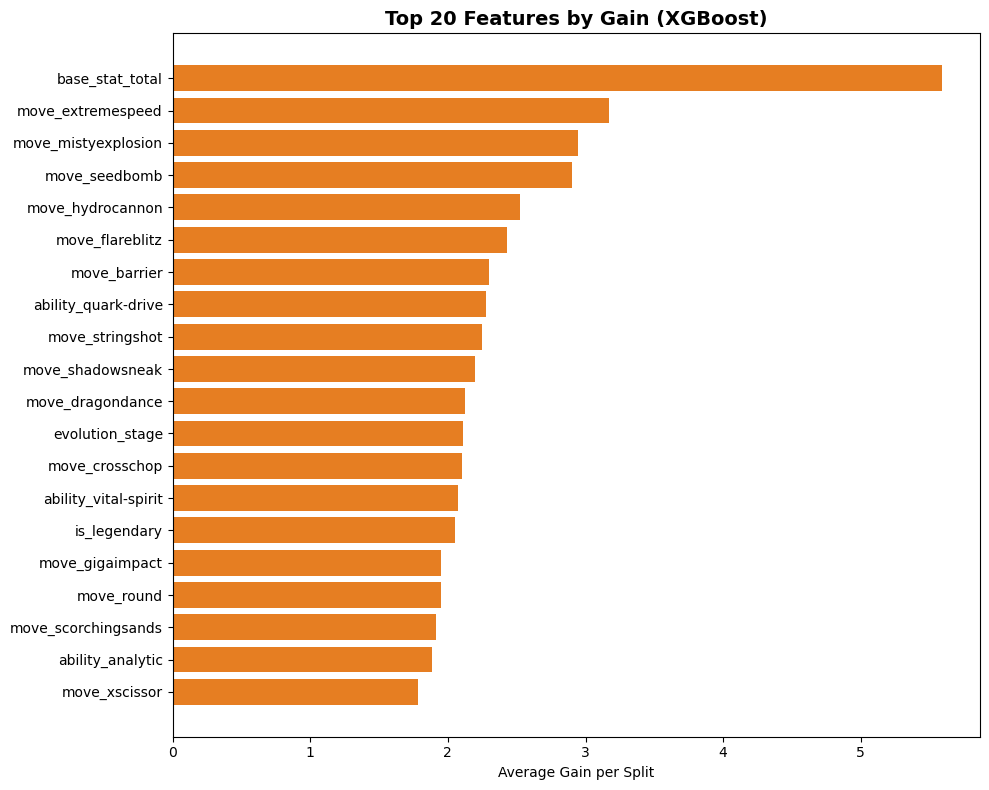

In [12]:
# Get importance dictionary (default is 'gain')
importance_dict = tier_model.get_booster().get_score(importance_type='gain')

# Convert to DataFrame and sort
feature_importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'].head(20), feature_importance_df['importance'].head(20), color='#e67e22')
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Gain (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Average Gain per Split')
plt.tight_layout()
plt.show()

In [13]:
tier_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    max_features='sqrt',
    random_state=seed,
    class_weight='balanced_subsample' # chose because some tiers have very few mons
)

tier_rf.fit(X_train, y_train.values.ravel())
rf_predictions = tier_rf.predict(X_test)

# evaluate
print("--- Random Forest Tier Prediction Results ---")
print(classification_report(y_test, rf_predictions, zero_division=0))

--- Random Forest Tier Prediction Results ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        64
           1       1.00      0.50      0.67        30
           2       0.72      0.95      0.82        91
           3       0.00      0.00      0.00         9
           4       0.00      0.00      0.00        11
           5       0.67      0.55      0.60        11

    accuracy                           0.79       216
   macro avg       0.54      0.50      0.50       216
weighted avg       0.74      0.79      0.74       216



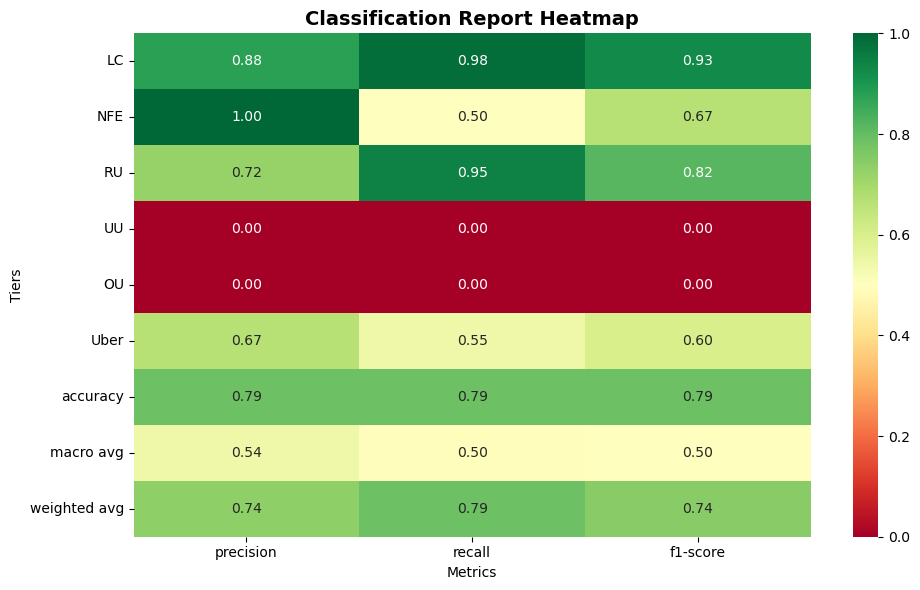

In [14]:
report_dict = classification_report(y_test, rf_predictions, target_names=tier_labels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax)

ax.set_title('Classification Report Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrics')
ax.set_ylabel('Tiers')

plt.tight_layout()
plt.show()

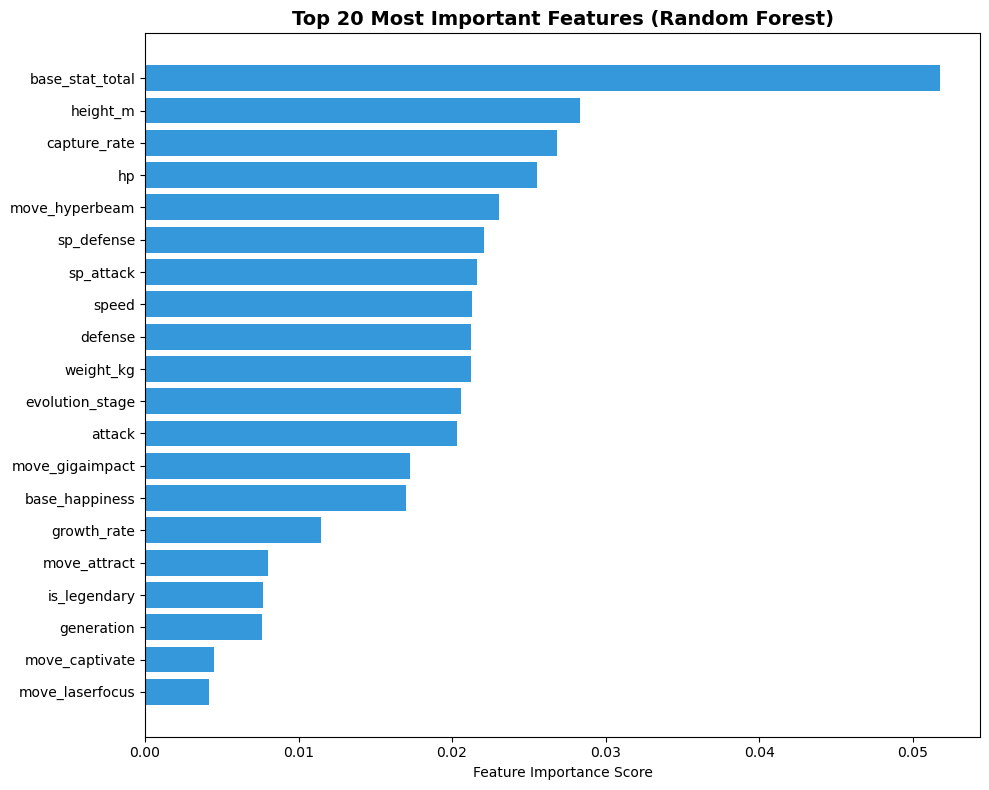

In [17]:
importances = tier_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'].head(20), feature_importance_df['importance'].head(20), color='#3498db')
plt.gca().invert_yaxis()
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

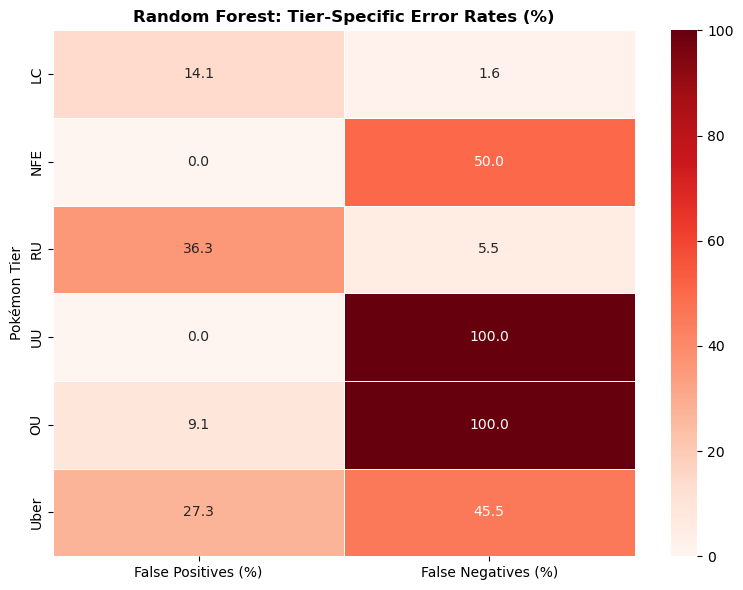

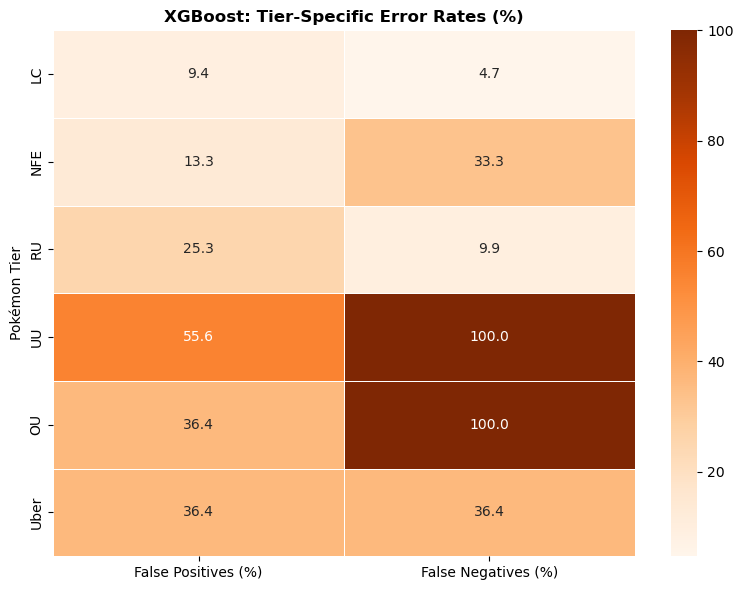

In [29]:
# y_test -> 1d list
y_test_flat = np.asarray(y_test).ravel()

# counts per tier
support = pd.Series(y_test_flat).value_counts().reindex(range(len(tier_labels)), fill_value=0)
support.index = tier_labels

# Function for plotting
def plot_model_heatmap(fp, fn, support_vals, title, cmap):
    # Ensure no division by zero for rare tiers
    safe_support = support_vals.replace(0, 1)
    
    rates = pd.DataFrame({
        'False Positives (%)': (fp / safe_support) * 100,
        'False Negatives (%)': (fn / safe_support) * 100
    }, index=tier_labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(rates, annot=True, cmap=cmap, fmt='.1f', linewidths=.5)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.ylabel('Pokémon Tier')
    plt.tight_layout()
    plt.show()

# Generate the two separate heatmaps, 1 for each model
plot_model_heatmap(comparison_df['FP_RF'].values, 
                   comparison_df['FN_RF'].values, 
                   support, 
                   'Random Forest: Tier-Specific Error Rates (%)', 
                   'Reds')

plot_model_heatmap(comparison_df['FP_XGB'].values, 
                   comparison_df['FN_XGB'].values, 
                   support, 
                   'XGBoost: Tier-Specific Error Rates (%)', 
                   'Oranges')

In [30]:
def trace_leakage(y_true, y_pred, target_idx, labels):
    # Ensure they are flat arrays
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    
    # Isolate only the instances of the target tier
    target_mask = (y_true == target_idx)
    predictions_for_target = y_pred[target_mask]
    
    # Count how many were predicted as each tier
    leakage = pd.Series(predictions_for_target).value_counts().reindex(range(len(labels)), fill_value=0)
    leakage.index = labels
    return leakage

# 3 is UU, 4 is OU
ou_leakage_rf = trace_leakage(y_test, rf_predictions, 4, tier_labels)
ou_leakage_xgb = trace_leakage(y_test, predictions, 4, tier_labels)

uu_leakage_rf = trace_leakage(y_test, rf_predictions, 3, tier_labels)
uu_leakage_xgb = trace_leakage(y_test, predictions, 3, tier_labels)

print("Actual OU Pokémon were predicted as:")
print(pd.DataFrame({'RF': ou_leakage_rf, 'XGB': ou_leakage_xgb}))

print("\nActual UU Pokémon were predicted as:")
print(pd.DataFrame({'RF': uu_leakage_rf, 'XGB': uu_leakage_xgb}))

Actual OU Pokémon were predicted as:
      RF  XGB
LC     0    0
NFE    0    0
RU    10    6
UU     0    3
OU     0    0
Uber   1    2

Actual UU Pokémon were predicted as:
      RF  XGB
LC     0    0
NFE    0    1
RU     9    8
UU     0    0
OU     0    0
Uber   0    0
